In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')
os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../results/metrics', exist_ok=True)

# Load processed data
train = pd.read_csv('../data/processed/train.csv',
                    index_col='Datetime',
                    parse_dates=True)

test = pd.read_csv('../data/processed/test.csv',
                   index_col='Datetime',
                   parse_dates=True)

# For ARIMA we only need the target column
train_arima = train['energy_mw']
test_arima  = test['energy_mw']

print(f"Train shape : {train_arima.shape}")
print(f"Test shape  : {test_arima.shape}")
print(f"\nTrain period: {train_arima.index.min().date()} → {train_arima.index.max().date()}")
print(f"Test period : {test_arima.index.min().date()} → {test_arima.index.max().date()}")
print(f"\nTrain stats:")
print(train_arima.describe().round(2))

Train shape : (5114,)
Test shape  : (580,)

Train period: 2003-01-01 → 2016-12-31
Test period : 2017-01-01 → 2018-08-03

Train stats:
count     5114.00
mean     32207.21
std       4595.93
min      21944.42
25%      28740.43
50%      31541.94
75%      35181.49
max      47839.58
Name: energy_mw, dtype: float64


In [2]:
from statsmodels.tsa.arima.model import ARIMA
import time

# Use last 2 years of training data for ARIMA
train_arima_short = train_arima.loc['2015-01-01':'2016-12-31']

print(f"ARIMA training rows : {len(train_arima_short)}")
print(f"Period              : {train_arima_short.index.min().date()} → {train_arima_short.index.max().date()}")
print(f"\nFitting ARIMA(1,0,1)... please wait")

# Start timer
start_time = time.time()

# Fit ARIMA model
model_arima = ARIMA(
    train_arima_short,
    order=(1, 0, 1)   # (p, d, q)
)

result_arima = model_arima.fit()

# End timer
elapsed = time.time() - start_time

print(f"✅ ARIMA fitted successfully!")
print(f"⏱️  Time taken : {elapsed:.1f} seconds")
print(f"\nModel Summary:")
print(result_arima.summary())

ARIMA training rows : 731
Period              : 2015-01-01 → 2016-12-31

Fitting ARIMA(1,0,1)... please wait


C:\Users\NB00569\Projects\energy-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\NB00569\Projects\energy-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\NB00569\Projects\energy-demand-forecasting\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


✅ ARIMA fitted successfully!
⏱️  Time taken : 0.3 seconds

Model Summary:
                               SARIMAX Results                                
Dep. Variable:              energy_mw   No. Observations:                  731
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -6649.498
Date:                Sun, 05 Apr 2026   AIC                          13306.996
Time:                        18:16:54   BIC                          13325.374
Sample:                    01-01-2015   HQIC                         13314.086
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       3.152e+04    622.766     50.609      0.000    3.03e+04    3.27e+04
ar.L1          0.8014      0.025     32.420      0.000   

In [3]:
# Forecast exactly as many steps as test set
forecast_steps = len(test_arima)

print(f"Forecasting {forecast_steps} days ahead...")

# Generate forecast
forecast_result = result_arima.forecast(steps=forecast_steps)

# Create forecast series with correct dates
forecast_arima = pd.Series(
    forecast_result.values,
    index=test_arima.index,
    name='forecast'
)

print(f"✅ Forecast generated successfully!")
print(f"\nForecast period : {forecast_arima.index.min().date()} → {forecast_arima.index.max().date()}")
print(f"Forecast steps  : {len(forecast_arima)}")
print(f"\nSample forecasts (first 5 days):")

comparison = pd.DataFrame({
    'Actual'   : test_arima.values[:5],
    'Forecast' : forecast_arima.values[:5],
    'Diff'     : test_arima.values[:5] - forecast_arima.values[:5]
}, index=test_arima.index[:5])

print(comparison.round(2))

Forecasting 580 days ahead...
✅ Forecast generated successfully!

Forecast period : 2017-01-01 → 2018-08-03
Forecast steps  : 580

Sample forecasts (first 5 days):
              Actual  Forecast     Diff
Datetime                               
2017-01-01  27292.88  30536.52 -3243.64
2017-01-02  30260.00  30731.40  -471.40
2017-01-03  31555.04  30887.57   667.47
2017-01-04  30889.33  31012.72  -123.39
2017-01-05  34968.62  31113.01  3855.61


In [4]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_model(actual, predicted, model_name):
    """Calculate and display evaluation metrics"""
    
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae  = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print('=' * 45)
    print(f'   {model_name} — Performance Metrics')
    print('=' * 45)
    print(f'  RMSE : {rmse:>10,.2f} MW')
    print(f'  MAE  : {mae:>10,.2f} MW')
    print(f'  MAPE : {mape:>10,.2f} %')
    print('=' * 45)
    
    return {'model': model_name, 
            'RMSE': round(rmse, 2),
            'MAE' : round(mae, 2),
            'MAPE': round(mape, 2)}

# Evaluate ARIMA
arima_metrics = evaluate_model(
    actual    = test_arima.values,
    predicted = forecast_arima.values,
    model_name= 'ARIMA(1,0,1)'
)

   ARIMA(1,0,1) — Performance Metrics
  RMSE :   4,507.38 MW
  MAE  :   3,684.67 MW
  MAPE :      12.03 %


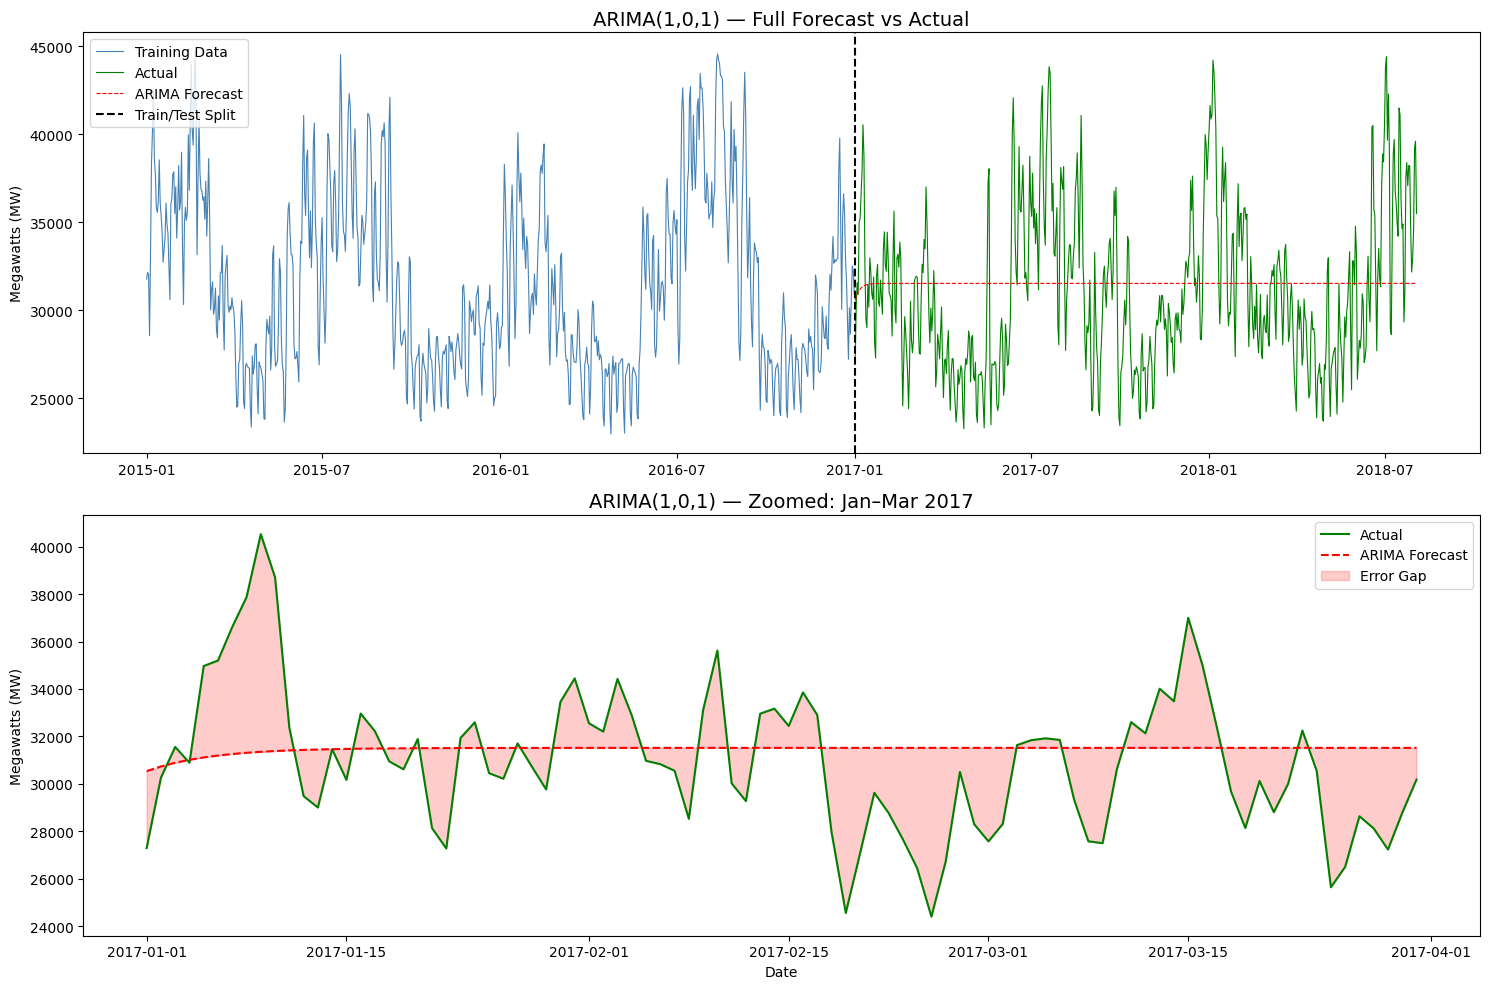

✅ Forecast plot saved


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1 — Full picture (train + forecast)
axes[0].plot(train_arima.loc['2015-01-01':],
             linewidth=0.8,
             color='steelblue',
             label='Training Data')
axes[0].plot(test_arima,
             linewidth=0.8,
             color='green',
             label='Actual')
axes[0].plot(forecast_arima,
             linewidth=0.8,
             color='red',
             linestyle='--',
             label='ARIMA Forecast')
axes[0].axvline(x=pd.Timestamp('2017-01-01'),
                color='black',
                linestyle='--',
                linewidth=1.5,
                label='Train/Test Split')
axes[0].set_title('ARIMA(1,0,1) — Full Forecast vs Actual', fontsize=14)
axes[0].set_ylabel('Megawatts (MW)')
axes[0].legend()

# Plot 2 — Zoom into first 3 months of forecast
zoom_actual   = test_arima.loc['2017-01-01':'2017-03-31']
zoom_forecast = forecast_arima.loc['2017-01-01':'2017-03-31']

axes[1].plot(zoom_actual,
             linewidth=1.5,
             color='green',
             label='Actual')
axes[1].plot(zoom_forecast,
             linewidth=1.5,
             color='red',
             linestyle='--',
             label='ARIMA Forecast')
axes[1].fill_between(zoom_actual.index,
                     zoom_actual,
                     zoom_forecast,
                     alpha=0.2,
                     color='red',
                     label='Error Gap')
axes[1].set_title('ARIMA(1,0,1) — Zoomed: Jan–Mar 2017', fontsize=14)
axes[1].set_ylabel('Megawatts (MW)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/plots/12_arima_forecast.png', dpi=150)
plt.show()

print("✅ Forecast plot saved")

In [6]:
import json

# Save forecast values
forecast_df = pd.DataFrame({
    'actual'   : test_arima.values,
    'forecast' : forecast_arima.values,
    'error'    : test_arima.values - forecast_arima.values,
    'pct_error': ((test_arima.values - forecast_arima.values) 
                  / test_arima.values * 100)
}, index=test_arima.index)

forecast_df.to_csv('../results/metrics/arima_forecasts.csv')
print("✅ Forecasts saved: results/metrics/arima_forecasts.csv")

# Save metrics to JSON
metrics_all = {'ARIMA(1,0,1)': arima_metrics}

with open('../results/metrics/model_comparison.json', 'w') as f:
    json.dump(metrics_all, f, indent=4)
print("✅ Metrics saved : results/metrics/model_comparison.json")

# Print final summary
print('\n' + '=' * 50)
print('        ARIMA — DAY 4 SUMMARY')
print('=' * 50)
print(f'\n  Model        : ARIMA(1,0,1)')
print(f'  Train period : 2015-01-01 → 2016-12-31')
print(f'  Test period  : 2017-01-01 → 2018-08-03')
print(f'  Forecast days: 580')
print(f'\n  RMSE         : 4,507.38 MW')
print(f'  MAE          : 3,684.67 MW')
print(f'  MAPE         : 12.03%')
print(f'\n  Verdict      : ❌ Poor — misses seasonality')
print(f'  Next step    : STLM to handle seasonality')
print('=' * 50)

✅ Forecasts saved: results/metrics/arima_forecasts.csv
✅ Metrics saved : results/metrics/model_comparison.json

        ARIMA — DAY 4 SUMMARY

  Model        : ARIMA(1,0,1)
  Train period : 2015-01-01 → 2016-12-31
  Test period  : 2017-01-01 → 2018-08-03
  Forecast days: 580

  RMSE         : 4,507.38 MW
  MAE          : 3,684.67 MW
  MAPE         : 12.03%

  Verdict      : ❌ Poor — misses seasonality
  Next step    : STLM to handle seasonality


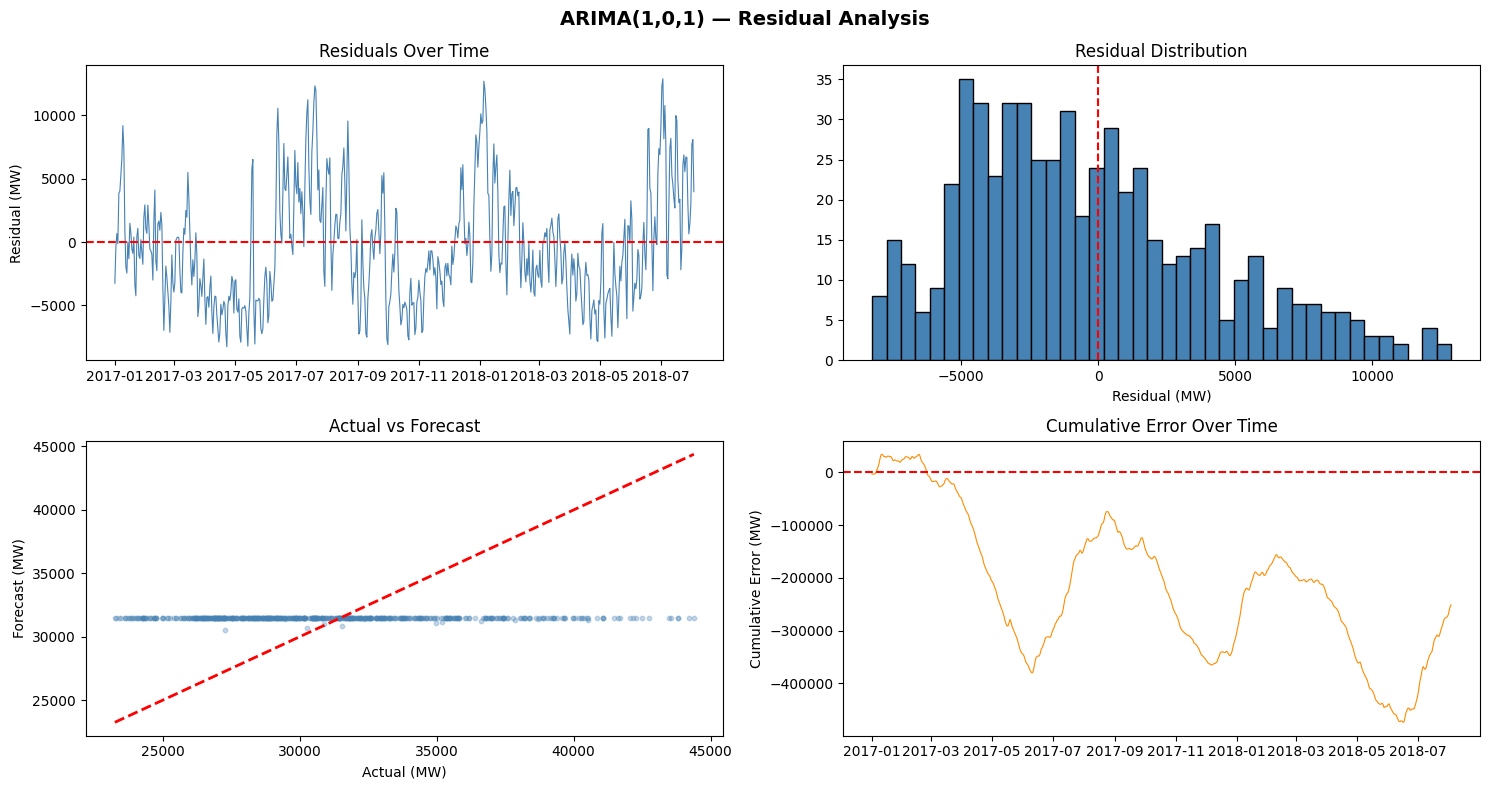

✅ Residual analysis saved


In [7]:
# Residuals = actual - forecast
residuals = test_arima.values - forecast_arima.values

fig, axes = plt.subplots(2, 2, figsize=(15, 8))

# Plot 1 — Residuals over time
axes[0,0].plot(test_arima.index, residuals,
               linewidth=0.8, color='steelblue')
axes[0,0].axhline(y=0, color='red', linestyle='--')
axes[0,0].set_title('Residuals Over Time')
axes[0,0].set_ylabel('Residual (MW)')

# Plot 2 — Residual distribution
axes[0,1].hist(residuals, bins=40, 
               color='steelblue', edgecolor='black')
axes[0,1].axvline(x=0, color='red', linestyle='--')
axes[0,1].set_title('Residual Distribution')
axes[0,1].set_xlabel('Residual (MW)')

# Plot 3 — Actual vs Forecast scatter
axes[1,0].scatter(test_arima.values, 
                  forecast_arima.values,
                  alpha=0.3, color='steelblue', s=10)
axes[1,0].plot([test_arima.min(), test_arima.max()],
               [test_arima.min(), test_arima.max()],
               color='red', linestyle='--', linewidth=2)
axes[1,0].set_title('Actual vs Forecast')
axes[1,0].set_xlabel('Actual (MW)')
axes[1,0].set_ylabel('Forecast (MW)')

# Plot 4 — Cumulative error
axes[1,1].plot(test_arima.index,
               np.cumsum(residuals),
               linewidth=0.8, color='darkorange')
axes[1,1].axhline(y=0, color='red', linestyle='--')
axes[1,1].set_title('Cumulative Error Over Time')
axes[1,1].set_ylabel('Cumulative Error (MW)')

plt.suptitle('ARIMA(1,0,1) — Residual Analysis', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/13_arima_residuals.png', dpi=150)
plt.show()

print("✅ Residual analysis saved")